<a href="https://colab.research.google.com/github/Valeria-YL/2047880MINERIA/blob/main/PIA/PIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***PIA - REPORTE***

Mínera de Datos

Valeria Ybarra López

Matricula : 2047880

Conjunto de datos encontrado en kaggle: https://www.kaggle.com/datasets/sumedh1507/blood-donor-dataset/data

In [1]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN

path = kagglehub.dataset_download("sumedh1507/blood-donor-dataset")
df = pd.read_csv(os.path.join(path, "blood_donor_dataset.csv"))

100%|██████████| 484k/484k [00:00<00:00, 72.6MB/s]

Extracting files...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   donor_id                     10000 non-null  object
 1   name                         10000 non-null  object
 2   email                        10000 non-null  object
 3   password                     10000 non-null  object
 4   contact_number               10000 non-null  object
 5   city                         10000 non-null  object
 6   blood_group                  10000 non-null  object
 7   availability                 10000 non-null  object
 8   months_since_first_donation  10000 non-null  int64 
 9   number_of_donation           10000 non-null  int64 
 10  pints_donated                10000 non-null  int64 
 11  created_at                   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


In [3]:
df.head()

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1b8b4c828a,Norma Fisher,ysullivan@yahoo.com,P5hX6Syg*A,+61 461706749,Hobart,A+,No,65,31,62,2017-03-17
1,a6a3f7fe55,Eugene Bowman,hramos@brown-sellers.com,b6Wq6Cqz@5,+61 450709944,Darwin,AB-,Yes,64,8,16,2016-11-11
2,cee6478144,Sheri Bolton DDS,jasmine85@hotmail.com,$9RB51m#s7,+61 428756361,Melbourne,AB+,Yes,39,6,6,2022-02-25
3,5986bc55f9,Kelly Boyd,pattylawrence@riley-hayes.com,@5Tdg(4kCm,+61 454318320,Darwin,A-,No,55,20,20,2025-04-04
4,93246afe6c,Taylor Guzman,martinezjacob@wilson.com,x!)9Ag@J*7,+61 484158472,Darwin,O-,No,7,35,35,2022-11-30


In [4]:
df['availability'].value_counts()

,count
availability,
Yes,5085
No,4915


**CLUSTERING**

Selecciono únicamente las columnas 'blood_group' y 'availability' del DataFrame, y las almaceno en una nueva variable X .

In [6]:
features = ['blood_group', 'availability']
X = df[features]

Aplicamos One-Hot Encoding para transformar las variables categóricas en vectores numéricos binarios.

In [7]:
X_encoded = pd.get_dummies(X, columns=features, drop_first=False)

In [8]:
#DBSCAN
dbscan = DBSCAN(eps=0.1, min_samples=20)
clusters = dbscan.fit_predict(X_encoded)

In [9]:
# Añadimos los clusters al DataFrame original
df['cluster'] = clusters

In [10]:
# Agrupamos por grupo sanguíneo y disponibilidad, mostrando la cantidad en cada cluster
grouped = df.groupby(['blood_group', 'availability', 'cluster']).size().reset_index(name='count')

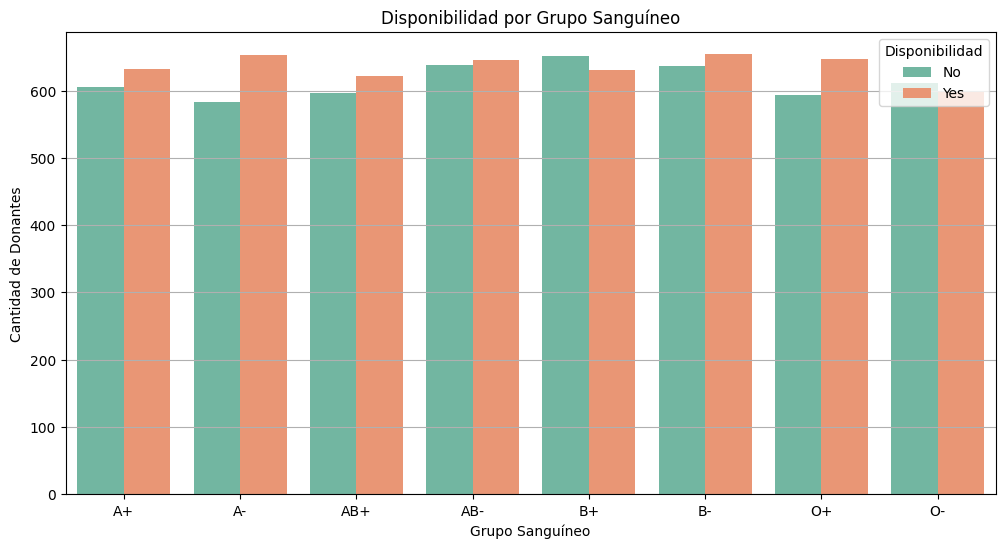

In [11]:
# Gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
sns.barplot(
    x='blood_group',
    y='count',
    hue='availability',
    data=grouped[grouped['cluster'] != -1],
    palette='Set2'
)
plt.title('Disponibilidad por Grupo Sanguíneo')
plt.xlabel('Grupo Sanguíneo')
plt.ylabel('Cantidad de Donantes')
plt.legend(title='Disponibilidad')
plt.grid(axis='y')
plt.show()


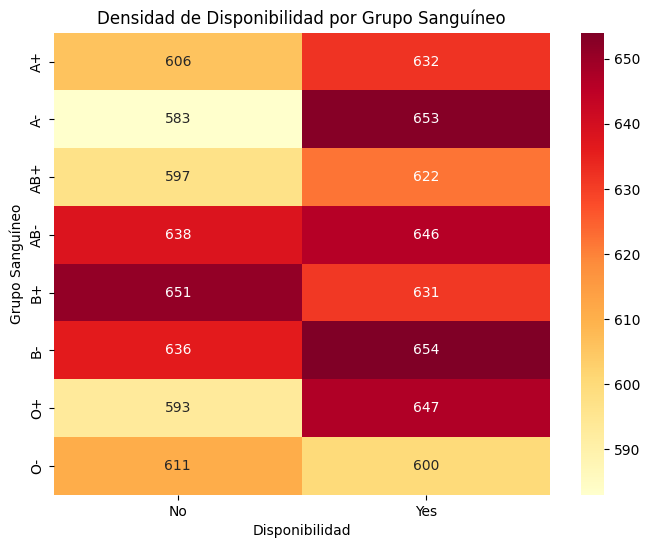

In [12]:
heat_data = df.groupby(['blood_group', 'availability']).size().unstack(fill_value=0)

# Mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Densidad de Disponibilidad por Grupo Sanguíneo')
plt.xlabel('Disponibilidad')
plt.ylabel('Grupo Sanguíneo')
plt.show()